<a href="https://colab.research.google.com/github/malehzja/lis4693/blob/main/lab-4/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Supervised Machine Learning

In this lab assignment, we will learn to perform supervised machine learning using `sklearn` library. I would highly recommend that you go through its documentation to learn more about performing different types of ML tasks like classification, regression, clustering, model selection and dimensionality reduction here: https://scikit-learn.org/stable/


*Note: Before starting this lab assignment, please complete the Introduction to Machine Learning notebook*

## Leaning Objectives

In this exercise, you will:

- Load and process the assigned data file
- Identify `features` and `target` labels for your dataset
- Split your data into test and training sets
- Perform text-preprocessing
- Compare different classifiers' performances based on their evaluation metrics (accuracy, precision, recall, f1-score) and pick the best one for your dataset
- Visualize the confusion matrix results
- Finally, use the classifier to run on unseen (new) data to make predictions


This exercise builds directly on concepts from discussed in the precursor notebook on "Introduction to Machine Learning".

## ✅ **TASK 1: Load the assigned dataset from your GitHub repo and determine the text data (features) and the target labels for the machine learning task**.

## Install and Load Libraries

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


##**1.1 Load and read your file from GitHub (Mine comes from BBC News)**

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/lis4693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

Saving it as a DataFrame using `df` variable that holds pandas DataFrame and seeing how it looks!

In [4]:
import pandas as pd

df = pd.read_csv(io.StringIO(text), sep='\t')  # The file is tab separated, you should specify sep='\t' while using the pandas.read_csv()
print(df.head())

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


##**1.2 Determine text data **features** and **target** labels**

In [5]:
features = df['content']
target = df['category']

In [8]:
# This ensures the taregt names are the names of the categories.

target_names = df['category'].unique()
print (target_names)

['business' 'entertainment' 'politics' 'sport' 'tech']


**Briefly explain your rationale for choosing these columns and how they will be used in the classification process.**  
For this dataset, as I showed above, my features will be **content** and target will be **category**. The reason for this is I want to train the machine to predict what category the/a article would be put in: business, entertainment, politics, sport, or tech.

## ✅ **TASK 2: Split the data into 70:30 ratio and perform text preprocessing.**

Now, I will prepare my data to get ready before feeding it into any machine learning classifiers.

I will first split the data into a test dataset (30%) and a training datset (70%) randomly in 70:30 ratio followed by text-preprocessing.

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 1557 samples.
Testing set has 668 samples.
Preprocessing training data...
Preprocessing test data...


In [11]:
y_test.unique()

array(['business', 'sport', 'politics', 'entertainment', 'tech'],
      dtype=object)

## ✅ **TASK 3: Train 3 classifiers of your choice using the training data. Evaluate and compare their performance using appropriate evaluation metrics such as accuracy, precision, recall, and F1-score**

Now, I will run 3 different classifiers (Naive Bayes, Support Vector Machine, Random Forest) on my dataset and see which one performs best based on the evaluation metrics (accuracy, precision, recall, f1 score). First I will only try accuracy.

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Random Forest classifier...


RandomForestClassifier()

In [13]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [17]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.9416167664670658
SVM Accuracy: 0.9730538922155688
RF Accuracy: 0.9535928143712575


The results above indicate that the **SVM** **classifier performed best**, achieving an **accuracy of 97%**. However, accuracy alone should not be the sole criterion for selecting a classifier. Other evaluation metrics, such as precision, recall, and F1-score, should also be considered to obtain a more comprehensive assessment of model performance.

Now, I will run the classification report for all 3 classifiers.

In [18]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, random_predictions, target_names=target_names))


               precision    recall  f1-score   support

     business       0.95      0.95      0.95       165
entertainment       0.99      0.82      0.90       118
     politics       0.93      0.97      0.95       120
        sport       0.90      0.99      0.94       140
         tech       0.96      0.97      0.96       125

     accuracy                           0.94       668
    macro avg       0.95      0.94      0.94       668
 weighted avg       0.94      0.94      0.94       668

               precision    recall  f1-score   support

     business       0.91      0.96      0.93       165
entertainment       0.98      0.93      0.96       118
     politics       0.97      0.94      0.95       120
        sport       0.95      0.99      0.97       140
         tech       0.97      0.94      0.96       125

     accuracy                           0.95       668
    macro avg       0.96      0.95      0.95       668
 weighted avg       0.95      0.95      0.95       668



The code from line 51-54 runs the classification report for Support Vactor Machine classifier.

In [19]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [20]:
print("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 10}


In [21]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.9745508982035929


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

               precision    recall  f1-score   support

     business       0.97      0.95      0.96       165
entertainment       0.97      0.98      0.97       118
     politics       0.95      0.97      0.96       120
        sport       0.99      0.99      0.99       140
         tech       0.98      0.98      0.98       125

     accuracy                           0.97       668
    macro avg       0.97      0.97      0.97       668
 weighted avg       0.97      0.97      0.97       668



**Briefly summarize your findings and explain which model performed best and why.**   
Based on all the classification reports for all the evaluation metrics across precision, recall, accuracy, and f1 score, SVM still performed the best. This was determined based on the f1-scores because it is said to balance precision and recall (NB = .94, Random = .95, SVM = .97).

## **3.1 Generate a confusion matrix for the best-performing classifier**

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0.5, 0, 'business'),
  Text(1.5, 0, 'sport'),
  Text(2.5, 0, 'politics'),
  Text(3.5, 0, 'entertainment'),
  Text(4.5, 0, 'tech')])

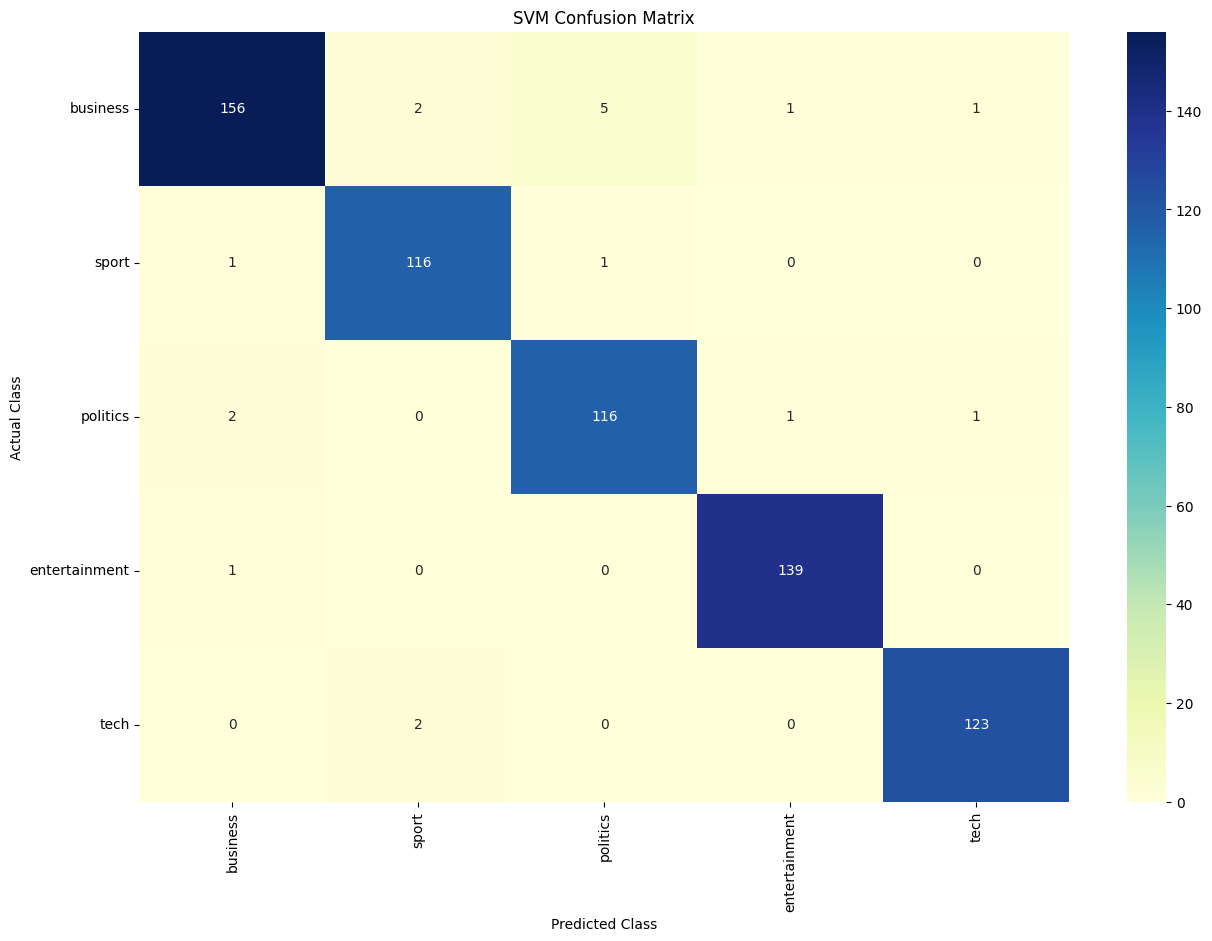

In [60]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, svm_predictions)

# Suppoed to ensure in order
target_names = list(y_test.unique())

conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.title("SVM Confusion Matrix") #Added for clarity
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

**Explain the results in your own words. Interpret what the values in the matrix represent in terms of correct and incorrect classifications.**   
The confusion matrix shows the number of articles that SVM correctly and incorrectly classified according to its given category. For example, the model correctly classified 156 Business articles but incorrectly labeled 1 as Sport, 2 as Politics, and 1 as Entertainment. Another example, the model correctly classified 139 entertainment articles as Entertainment, but misclassified 1 as Business and 1 as Politics.

## Supervised Machine Learning

## ✅ **TASK 4: Generate a pseudo CSV dataset with at least 100 rows related to the features of your chosen dataset using ChatGPT or another LLM. The generated dataset should be related to your original dataset (eg. if your dataset is on spam messages this pseudo dataset should also be on spam messages) with an empty target column. Add that file to GitHub.**

Now, I will use the machine learning model that selected with SVM Classifier to run on the data it has never seen to make predictions aka Supervised Machine Learning!

For this task, I will now upload new dataset with empty "category" column created in ChatGPT.

In [39]:
url = "https://raw.githubusercontent.com/malehzja/lis4693/refs/heads/main/lab-4/psuedo_dataset.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text # Store the raw CSV string

new_data = pd.read_csv(io.StringIO(raw_csv_data), sep=',')  # The file is comma separated, you should specify sep='\t' while using the panda.read_csv())
print(new_data.head())

print(new_data.columns)

   category     filename                title  \
0       NaN  doc_001.txt      Breaking News 1   
1       NaN  doc_002.txt  Sports Highlights 2   
2       NaN  doc_003.txt      Tech Insights 3   
3       NaN  doc_004.txt   Political Debate 4   
4       NaN  doc_005.txt       Market Watch 5   

                                             content  
0  This article covers the recent events in the t...  
1  Sports fans celebrate the team's victory in th...  
2       The government announced new policies today.  
3  Financial markets are volatile amid global eve...  
4  Health experts warn about new seasonal flu cases.  
Index(['category', 'filename', 'title', 'content'], dtype='object')


In [40]:
text = new_data['content']

In [41]:
text

,content
0,This article covers the recent events in the t...
1,Sports fans celebrate the team's victory in th...
2,The government announced new policies today.
3,Financial markets are volatile amid global eve...
4,Health experts warn about new seasonal flu cases.
...,...
95,Scientists discover new species in the rainfor...
96,This article covers the recent events in the t...
97,Sports fans celebrate the team's victory in th...
98,The government announced new policies today.


Now, I will do text-preprocessing.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [43]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

## Predicting Features: Fitting New Dataset

## **4.1 Use your trained machine learning model to perform supervised classification and predict the labels for this new pseudo dataset.**

Using the code below, I will use the SVM Classifier to make predictions based on my previously trained machine learning model.

Here the `fit()` method trains the SVM Classifier model using our training data:

- `dtm` represents the preprocessed training features. It's likely a Document-Term Matrix (DTM) or TF-IDF matrix generated from the text abstracts (X_train) during the text preprocessing steps.
- `y_train` is the corresponding target labels (e.g., for category research) for each sample in dtm.

After this line executes, classifier holds the trained machine learning model, ready to make predictions.

In [44]:
from sklearn.svm import LinearSVC
model = LinearSVC(C=10, max_iter=10000)
classif = model.fit(dtm, y_train)

The next line of code preprocesses the 'content' column content from the `new_data` DataFrame so that it's in the same format as the data the model was trained on.

In [45]:
test_dtm = vect.transform(new_data['content'])

Removing any empty values for contents

In [46]:
import pandas as pd

# Replace NaN values with an empty string before applying transform
new_data['content'] = new_data['content'].fillna('')
test_dtm = vect.transform(new_data['content'])

Using the code below, we are making predictions using our machine learning model for the `category` in our new dataset.

In [61]:
test = classif.predict(test_dtm)
print(test)

['business' 'sport' 'politics' 'business' 'politics' 'sport' 'business'
 'sport' 'politics' 'business' 'politics' 'sport' 'business' 'sport'
 'politics' 'business' 'politics' 'sport' 'business' 'sport' 'politics'
 'business' 'politics' 'sport' 'business' 'sport' 'politics' 'business'
 'politics' 'sport' 'business' 'sport' 'politics' 'business' 'politics'
 'sport' 'business' 'sport' 'politics' 'business' 'politics' 'sport'
 'business' 'sport' 'politics' 'business' 'politics' 'sport' 'business'
 'sport' 'politics' 'business' 'politics' 'sport' 'business' 'sport'
 'politics' 'business' 'politics' 'sport' 'business' 'sport' 'politics'
 'business' 'politics' 'sport' 'business' 'sport' 'politics' 'business'
 'politics' 'sport' 'business' 'sport' 'politics' 'business' 'politics'
 'sport' 'business' 'sport' 'politics' 'business' 'politics' 'sport'
 'business' 'sport' 'politics' 'business' 'politics' 'sport' 'business'
 'sport' 'politics' 'business' 'politics' 'sport' 'business' 'sport'
 'polit

Time to merge the metadata from the new_data file with the `category` column from df2 into the original new_data file that contains the empty column. This will allow us to reconstruct the complete dataset, which can then be shared with others or used for downstream analysis and processing.

In [54]:
new_data['category'] = test
combined_df = new_data


 ## **4.2 Manually review at least 10 rows from the predicted labels and discuss if the machine learning model accurately identified the labels or not.**

In [59]:
display(combined_df.head(10))

,category,filename,title,content
0,business,doc_001.txt,Breaking News 1,This article covers the recent events in the t...
1,sport,doc_002.txt,Sports Highlights 2,Sports fans celebrate the team's victory in th...
2,politics,doc_003.txt,Tech Insights 3,The government announced new policies today.
3,business,doc_004.txt,Political Debate 4,Financial markets are volatile amid global eve...
4,politics,doc_005.txt,Market Watch 5,Health experts warn about new seasonal flu cases.
5,sport,doc_006.txt,Science Report 6,Scientists discover new species in the rainfor...
6,business,doc_007.txt,Breaking News 7,This article covers the recent events in the t...
7,sport,doc_008.txt,Sports Highlights 8,Sports fans celebrate the team's victory in th...
8,politics,doc_009.txt,Tech Insights 9,The government announced new policies today.
9,business,doc_010.txt,Political Debate 10,Financial markets are volatile amid global eve...


**Report how many were correctly classified and how many were misclassified, and briefly share your insights about the model’s performance.**

Just looking at the first 10 articles, the model only correctly classified 5. SVM is not performing well with the empty columns. However, I do not think it is entirely the models fault. For some reason, the model did not categorize anything as tech or entertainment, so I can only guess something went wrong somewhere. It acted as if it was never trained with the categories.

## **4.3 Save the results, including the predicted labels, as a new CSV file named `predicted.csv` on GitHub**

Let's SAVE the combined data as a CSV file.

In [62]:
combined_df.to_csv('predicted_data.csv', index=False)

✅ **TASK 5: As a group/individual, share at the end of your Colab notebook, create a new text cell, and write a brief reflection for this assignment in a few sentences addressing the following:**


What went well?   
The main thing that went well with the lab was the ease of moving from task to task. The example document was layed out in a way that was easy to understand. I rarely had to look up terms this time.

What did not go well or what challenges you encountered?  
There were two main challenges and one that did not go well in this assignment. The first challenge I encountered was issues with reading in my csv files. I realized that the issue was not specifying comma or tab seperation. The second challenge was understanding the confusion matrix. I had to add labels for clarity. What did not go well was the categorization of my pseudo data. I am unsure why, but it seemed to overlook 2 categories. This was weird because the categories were present in training. Overall though, through the challenges and issues, I felt like I learned the most I have so far in this lab.